> ⚠️ **Engine v2: backtest KHÔNG còn look-ahead cùng ngày (`src/backtest.py`).** Output cũ đã được xóa vì tính bằng engine có look-ahead cùng ngày (bản cũ còn nguyên output: `notebooks/legacy_v1_outputs/`). **Chạy lại notebook này** để có số liệu mới; tổng hợp cả 3 chiến lược nằm ở `06_engine_v2_rerun.ipynb`.


# Backtest với Transaction Cost + Slippage

**Mục tiêu:** Test lại chiến lược Momentum + Exit Rules với transaction
cost và slippage — dùng GIỮ NGUYÊN giả định cost đã dùng ở project
`momentum-ridge-vn30`: **0.15% transaction cost + 0.08% slippage = 0.23% tổng**
mỗi lần đổi vị thế (mỗi BUY và mỗi SELL).

Đây là bước lấp khoảng trống lớn nhất đã nêu trong `reports/research_note.md`
Ngày 19: Sharpe 2.109 đo được KHÔNG có cost, có thể bị phóng đại.

**Cách cost được áp dụng** (xem `src/backtest.py::backtest_with_exits`,
tham số `cost_rate`):
- Mỗi lệnh BUY: phí = `cost_rate × (1/n_positions)` — tỷ trọng notional của vị thế mới trong portfolio.
- Mỗi lệnh SELL (toàn bộ hoặc một phần `size_sold`): phí = `cost_rate × size_sold / n_positions_trước_khi_bán`.
- Cost trừ trực tiếp vào `port_return` NGÀY phát sinh giao dịch (không phải trải đều).


In [1]:
# -*- coding: utf-8 -*-
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import VN30_UNIVERSE, load_ohlcv, filter_by_coverage
from src.momentum_factors import momentum_6_1, momentum_12_1
from src.feature_engineering import assemble_dataset, cross_sectional_rank
from src.ic_analysis import single_factor_ic
from src.strategy import composite_score, normalize_ic_weights
from src.backtest import backtest_with_exits, invested_returns, port_metrics, trade_statistics, calmar_ratio, TOTAL_COST_RATE, TRANSACTION_COST, SLIPPAGE
from src.risk import equal_weight_benchmark, compare_strategies

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
print(f"Transaction cost: {TRANSACTION_COST:.2%}")
print(f"Slippage:         {SLIPPAGE:.2%}")
print(f"Tổng cost/lệnh:    {TOTAL_COST_RATE:.2%}  (giữ nguyên giả định từ momentum-ridge-vn30)")


Transaction cost: 0.15%
Slippage:         0.08%
Tổng cost/lệnh:    0.23%  (giữ nguyên giả định từ momentum-ridge-vn30)


## 1. Tải dữ liệu + build lại composite score (giống Ngày 19)

In [2]:
START, END = "2022-01-01", "2025-12-31"

ohlcv = load_ohlcv(VN30_UNIVERSE, START, END, fields=("close", "open", "volume"))
price_df, volume_df = ohlcv["close"], ohlcv["volume"]
price_df, dropped = filter_by_coverage(price_df)
volume_df = volume_df[price_df.columns]
print(f"Universe: {len(price_df.columns)} mã (loại {dropped})")


[1/30] Loading ACB...


[2/30] Loading BID...
[3/30] Loading BSR...
[4/30] Loading CTG...
[5/30] Loading FPT...
[6/30] Loading GAS...
[7/30] Loading GVR...
[8/30] Loading HDB...
[9/30] Loading HPG...
[10/30] Loading LPB...
[11/30] Loading MBB...
[12/30] Loading MCH...


[13/30] Loading MSN...
[14/30] Loading MWG...
[15/30] Loading SAB...
[16/30] Loading SHB...
[17/30] Loading SSB...
[18/30] Loading SSI...
⏳ Nghỉ 65s để tránh rate limit...
[19/30] Loading STB...
[20/30] Loading TCB...
[21/30] Loading TCX...
[22/30] Loading VCB...
[23/30] Loading VHM...
[24/30] Loading VIB...
[25/30] Loading VIC...
[26/30] Loading VJC...
[27/30] Loading VNM...
[28/30] Loading VPB...
[29/30] Loading VPL...
[30/30] Loading VRE...

✅ Đã tải: 30/30 mã
Universe: 28 mã (loại ['TCX', 'VPL'])


In [3]:
returns_df = price_df.pct_change(fill_method=None)
vol_20 = returns_df.rolling(20).std()
vol_120 = returns_df.rolling(120).std()
vol_spike = vol_20 / vol_120

mom_6_1 = momentum_6_1(price_df)
mom_12_1 = momentum_12_1(price_df)
TARGET_VOL = 0.15 / np.sqrt(252)
ts_mom = np.sign(mom_12_1) * (TARGET_VOL / vol_20.replace(0, np.nan))

raw_factors = {
    "Momentum_6_1": mom_6_1, "Momentum_12_1": mom_12_1,
    "Volume_Ratio": volume_df / volume_df.rolling(20).mean(), "TS_Momentum": ts_mom,
}
feature_cols = list(raw_factors.keys())

dataset = assemble_dataset(raw_factors, price_df, n_fwd=5, label_type="regression")
sf_ic = single_factor_ic(dataset, feature_cols, n_splits=5, embargo=5)
print(sf_ic.round(4))

ic_weights = normalize_ic_weights(sf_ic)
ranked_factors = {name: cross_sectional_rank(f) for name, f in raw_factors.items()}
comp_score = composite_score(ranked_factors, ic_weights)
print(f"\nIC weights: {ic_weights}")


Momentum_6_1    0.0525
Momentum_12_1   0.0441
TS_Momentum     0.0335
Volume_Ratio    0.0058
Name: Mean IC, dtype: float64

IC weights: {'Momentum_6_1': 0.38638722593775626, 'Momentum_12_1': 0.32460485205383055, 'TS_Momentum': 0.24650685260862581, 'Volume_Ratio': 0.04250106939978736}


## 2. Backtest KHÔNG cost (baseline, tái tạo kết quả Ngày 19)

Chạy lại với `cost_rate=0.0` để có baseline so sánh — số liệu này PHẢI khớp
với kết quả đã báo cáo ở Ngày 19 (Sharpe ~2.1, xem `reports/research_note.md`).

In [4]:
port_no_cost, trade_no_cost = backtest_with_exits(
    price_df, comp_score, vol_spike, mom_6_1,
    stop_loss_pct=0.08, trail_pct=0.12, vol_exit_thr=3.0, vol_reduce_thr=2.0,
    top_entry_rank=0.65, signal_exit_rank=0.40, max_positions=10, rebal_freq=5,
    cost_rate=0.0,
)
ret_no_cost = port_no_cost["port_return"]
m_no_cost = port_metrics(invested_returns(port_no_cost))
m_no_cost["Calmar"] = calmar_ratio(m_no_cost)
print("=== KHÔNG CÓ COST (baseline Ngày 19) ===")
for k, v in m_no_cost.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


=== KHÔNG CÓ COST (baseline Ngày 19) ===
  Total Return: 1.8677
  Ann Return: 0.4309
  Ann Vol: 0.2053
  Sharpe: 2.0985
  Max DD: -0.1805
  Calmar: 2.3875


## 3. Backtest CÓ transaction cost + slippage (Ngày 20)

In [5]:
port_with_cost, trade_with_cost = backtest_with_exits(
    price_df, comp_score, vol_spike, mom_6_1,
    stop_loss_pct=0.08, trail_pct=0.12, vol_exit_thr=3.0, vol_reduce_thr=2.0,
    top_entry_rank=0.65, signal_exit_rank=0.40, max_positions=10, rebal_freq=5,
    cost_rate=TOTAL_COST_RATE,
)
ret_with_cost = port_with_cost["port_return"]
m_with_cost = port_metrics(invested_returns(port_with_cost))
m_with_cost["Calmar"] = calmar_ratio(m_with_cost)
print("=== CÓ TRANSACTION COST + SLIPPAGE (0.23%/lệnh) ===")
for k, v in m_with_cost.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

total_cost_paid = port_with_cost["cost"].sum()
print(f"\nTổng cost đã trả (tích lũy toàn bộ backtest): {total_cost_paid:.2%}")


=== CÓ TRANSACTION COST + SLIPPAGE (0.23%/lệnh) ===
  Total Return: 1.6133
  Ann Return: 0.3864
  Ann Vol: 0.2063
  Sharpe: 1.8731
  Max DD: -0.1867
  Calmar: 2.0697

Tổng cost đã trả (tích lũy toàn bộ backtest): 9.47%


## 4. So sánh: KHÔNG cost vs CÓ cost vs 1/N Benchmark

In [6]:
ew_ret = equal_weight_benchmark(price_df)

strategies = {
    "Momentum+Exits (KHÔNG cost)": invested_returns(port_no_cost),
    "Momentum+Exits (CÓ cost)": invested_returns(port_with_cost),
    "1/N Equal-Weight": ew_ret,
}
cmp_df = compare_strategies(strategies)
print(cmp_df.round(4).to_string())

sharpe_drop = m_no_cost["Sharpe"] - m_with_cost["Sharpe"]
sharpe_drop_pct = sharpe_drop / m_no_cost["Sharpe"] if m_no_cost["Sharpe"] else np.nan
print(f"\nSharpe giảm do cost: {sharpe_drop:.3f} ({sharpe_drop_pct:.1%} so với baseline không cost)")

still_beats_benchmark = m_with_cost["Sharpe"] > cmp_df.loc["1/N Equal-Weight", "Sharpe"]
print(f"Sau cost, chiến lược vẫn thắng 1/N benchmark: {'✅ CÓ' if still_beats_benchmark else '❌ KHÔNG'}")


                             Total Return  Ann Return  Ann Vol  Sharpe  Max DD  Calmar  Sharpe SE
Momentum+Exits (KHÔNG cost)        1.8677      0.4309   0.2053  2.0985 -0.1805  2.3875     0.5851
Momentum+Exits (CÓ cost)           1.6133      0.3864   0.2063  1.8731 -0.1867  2.0697     0.5848
1/N Equal-Weight                   1.0134      0.2687   0.1798  1.4944 -0.1681  1.5986     0.5843

Sharpe giảm do cost: 0.225 (10.7% so với baseline không cost)
Sau cost, chiến lược vẫn thắng 1/N benchmark: ✅ CÓ


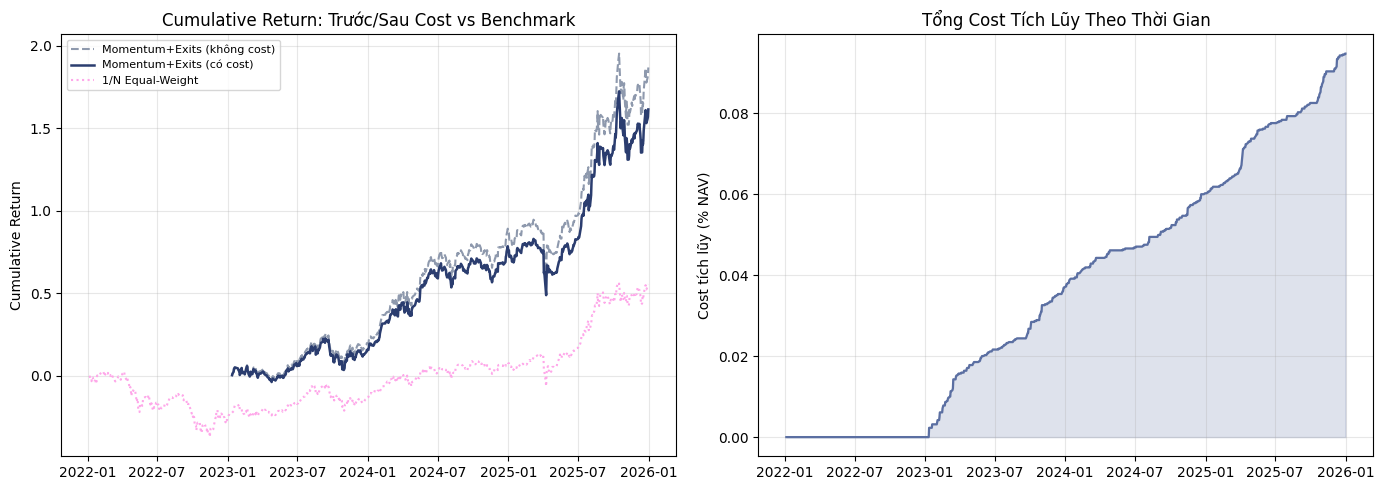

✅ Đã lưu: reports/day20_cost_impact.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cum_no_cost = (1 + invested_returns(port_no_cost)).cumprod() - 1
cum_with_cost = (1 + invested_returns(port_with_cost)).cumprod() - 1
cum_ew = (1 + ew_ret).cumprod() - 1

ax = axes[0]
ax.plot(cum_no_cost.index, cum_no_cost.values, label="Momentum+Exits (không cost)", color="#8e99ad", linewidth=1.5, linestyle="--")
ax.plot(cum_with_cost.index, cum_with_cost.values, label="Momentum+Exits (có cost)", color="#2b3d6f", linewidth=1.8)
ax.plot(cum_ew.index, cum_ew.values, label="1/N Equal-Weight", color="#fea7e9", linewidth=1.5, linestyle=":")
ax.set_title("Cumulative Return: Trước/Sau Cost vs Benchmark")
ax.set_ylabel("Cumulative Return")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
cost_cum = port_with_cost["cost"].cumsum()
ax2.plot(cost_cum.index, cost_cum.values, color="#5b6fa2", linewidth=1.6)
ax2.fill_between(cost_cum.index, 0, cost_cum.values, alpha=0.2, color="#5b6fa2")
ax2.set_title("Tổng Cost Tích Lũy Theo Thời Gian")
ax2.set_ylabel("Cost tích lũy (% NAV)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/day20_cost_impact.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Đã lưu: reports/day20_cost_impact.png")


## 5. Turnover Analysis — cost đến từ đâu?

Với `rebal_freq=5` (rebalance mỗi 5 ngày) và `max_positions=10`, tần suất
giao dịch là yếu tố chính quyết định tổng cost. Kiểm tra số lệnh/tháng và
cost trung bình mỗi lệnh.

In [8]:
n_buys = trade_statistics(trade_with_cost).get("n_buys", 0)
n_sells = trade_statistics(trade_with_cost).get("n_sells", 0)
n_days_total = len(price_df)
n_months = n_days_total / 21

print(f"Tổng số lệnh: {n_buys + n_sells} ({n_buys} buy + {n_sells} sell)")
print(f"Số lệnh/tháng trung bình: {(n_buys + n_sells) / n_months:.1f}")
print(f"Cost trung bình/lệnh: {total_cost_paid / (n_buys + n_sells):.4%}" if (n_buys + n_sells) > 0 else "N/A")
print(f"\nTổng cost tích lũy: {total_cost_paid:.2%} trên tổng {n_months:.0f} tháng")
print(f"→ Cost trung bình: {total_cost_paid / n_months:.3%}/tháng")


Tổng số lệnh: 378 (191 buy + 187 sell)
Số lệnh/tháng trung bình: 8.0
Cost trung bình/lệnh: 0.0251%

Tổng cost tích lũy: 9.47% trên tổng 47 tháng
→ Cost trung bình: 0.200%/tháng


## 6. Kết luận Ngày 20 — Trung thực về tác động cost

So sánh trực tiếp Sharpe TRƯỚC và SAU cost, và liệu chiến lược có còn thắng
1/N benchmark hay không. Nếu cost ăn mòn phần lớn alpha — đây là kết quả
QUAN TRỌNG cần ghi rõ, không che giấu hay tối thiểu hóa.

Cập nhật `reports/research_note.md` mục 7 (Backtest với Exit Rules) với số
liệu CÓ COST từ notebook này — thay thế cảnh báo "chưa có transaction cost"
bằng kết quả thực tế.

In [9]:
print("=" * 65)
print("TÓM TẮT NGÀY 20")
print("=" * 65)
print(f"Sharpe KHÔNG cost:  {m_no_cost['Sharpe']:.3f}")
print(f"Sharpe CÓ cost:     {m_with_cost['Sharpe']:.3f}")
print(f"Sharpe 1/N:         {cmp_df.loc['1/N Equal-Weight', 'Sharpe']:.3f}")
print(f"\nCòn thắng benchmark sau cost: {'✅ CÓ' if still_beats_benchmark else '❌ KHÔNG'}")
print(f"Tổng cost đã trả:   {total_cost_paid:.2%} (trên toàn bộ giai đoạn backtest)")


TÓM TẮT NGÀY 20
Sharpe KHÔNG cost:  2.098
Sharpe CÓ cost:     1.873
Sharpe 1/N:         1.494

Còn thắng benchmark sau cost: ✅ CÓ
Tổng cost đã trả:   9.47% (trên toàn bộ giai đoạn backtest)
